### For each cell type, identify the number of significant genes for meta-analysis and covariate

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
cell_types <- c("Adipocyte", "Cardiomyocyte", "Endocardial", "Endothelial",
                "Fibroblast", "Lymphoid", "LEC", "Mast", "Myeloid", "Neuronal", "Pericyte", "vSMC")

In [3]:
directions <- c("up", "down")

In [4]:
collect_sig_counts <- function(cell_types, directions, results_dir) {
  
  results_df <- data.frame(
    cell_type = character(),
    direction = character(),
    num_cov_sig = integer(),
    num_meta_sig = integer(),
    num_shared_sig = integer(),
    stringsAsFactors = FALSE
  )
  
  for (cell_type in cell_types) {
    for (direction in directions) {
      sig_df_path <- file.path(results_dir, paste0(cell_type, "_", direction, "_overlap_results.csv"))
      
      if (file.exists(sig_df_path)) {
        sig_df <- read.csv(sig_df_path)
        
        shared_df <- sig_df %>%
          filter(Covariate == 1 & Weighted.Fisher == 1)
        
        num_cov_sig <- sum(sig_df$Covariate)
        num_meta_sig <- sum(sig_df$Weighted.Fisher)
        num_shared_sig <- sum(shared_df$Weighted.Fisher)
        
      } else {
        num_cov_sig <- 0
        num_meta_sig <- 0
        num_shared_sig <- 0
      }
      
      results_df <- rbind(
        results_df,
        data.frame(
          cell_type = cell_type,
          direction = direction,
          num_cov_sig = num_cov_sig,
          num_meta_sig = num_meta_sig,
          num_shared_sig = num_shared_sig,
          stringsAsFactors = FALSE
        )
      )
    }
  }

  results_long <- results_df %>%
  pivot_longer(
    cols = c(num_cov_sig, num_meta_sig, num_shared_sig),
    names_to = "category",
    values_to = "count"
  )
  
  return(results_long)
}

In [5]:
plot_deg_bar <- function(results_long, fig_width = 15, fig_height = 6) {
  
  options(repr.plot.width = fig_width, repr.plot.height = fig_height)
  
  p <- ggplot(data = results_long, mapping = aes(x = cell_type, y = count, fill = direction)) +
    facet_wrap(~ category, ncol = 3) + 
    geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
    geom_text(aes(label = count), 
              position = position_dodge(width = 0.8), 
              vjust = -0.5, size = 5) +
    scale_fill_manual(values = c("up" = "blue", "down" = "red")) +
    theme_bw() +
    theme(
      legend.text = element_text(size = 16),
      legend.title = element_text(size = 16, color = "black"),
      plot.title = element_text(size = 24, hjust = 0.5, color = "black"),
      axis.title.x = element_text(size = 16, color = "black"),
      axis.title.y = element_text(size = 16, color = "black"),
      axis.text.x = element_text(size = 16, color = "black", hjust = 1, angle = 45),
      axis.text.y = element_text(size = 16, color = "black"),
      strip.text = element_text(size = 18, color = "black")
    ) +
    labs(x = "Cell Type", y = "Number of DEGs", fill = "Direction")
  
  return(p)
}

In [6]:
age_res_long = collect_sig_counts(cell_types = cell_types, directions = directions, results_dir = "age_results_dir/")

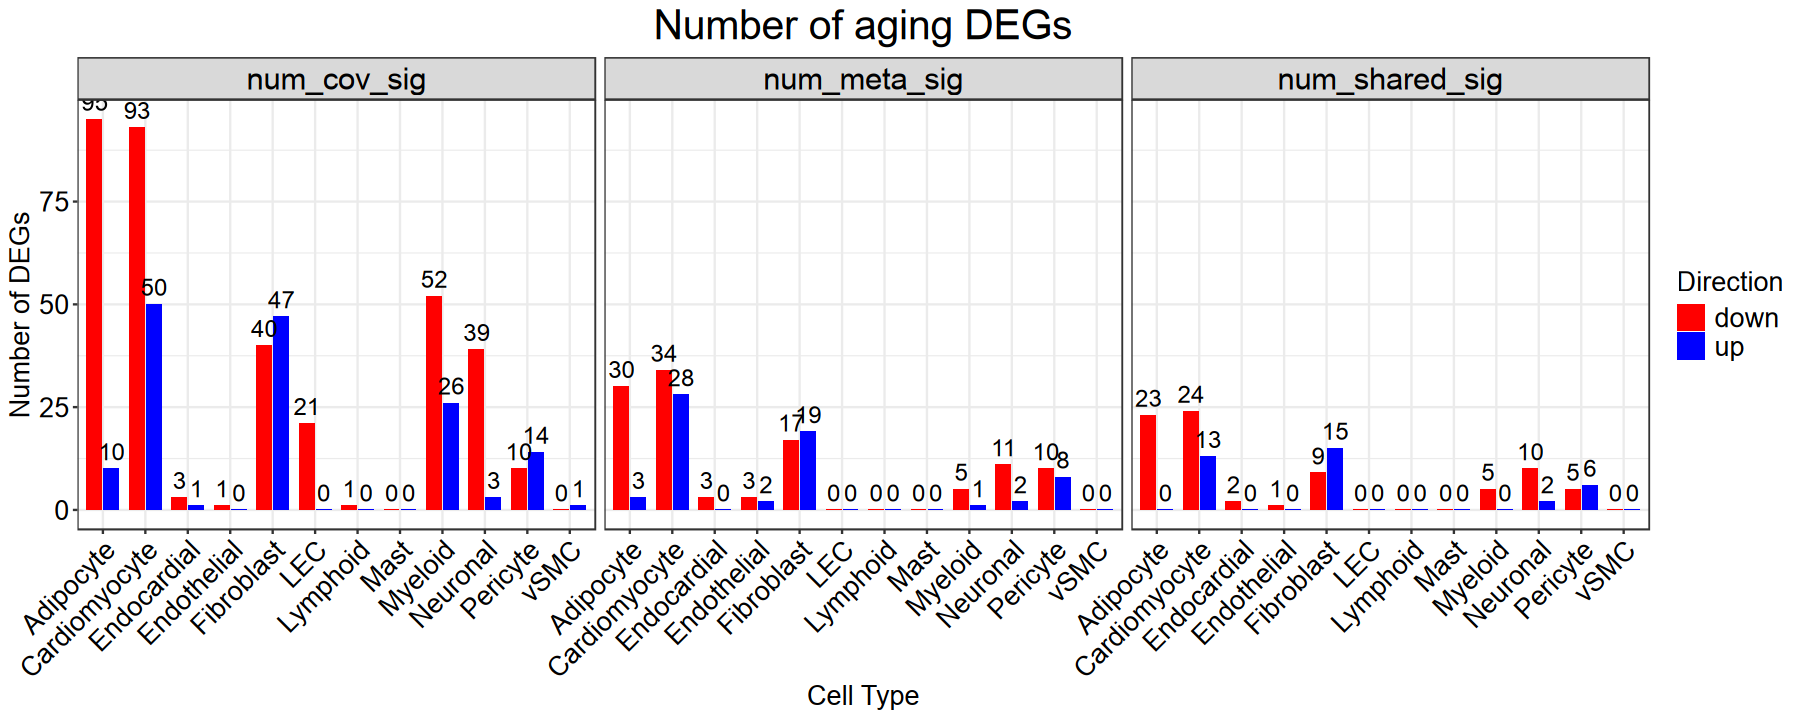

In [7]:
options(repr.plot.width = 15, repr.plot.height = 6)
plot_deg_bar(age_res_long) + ggtitle("Number of aging DEGs")

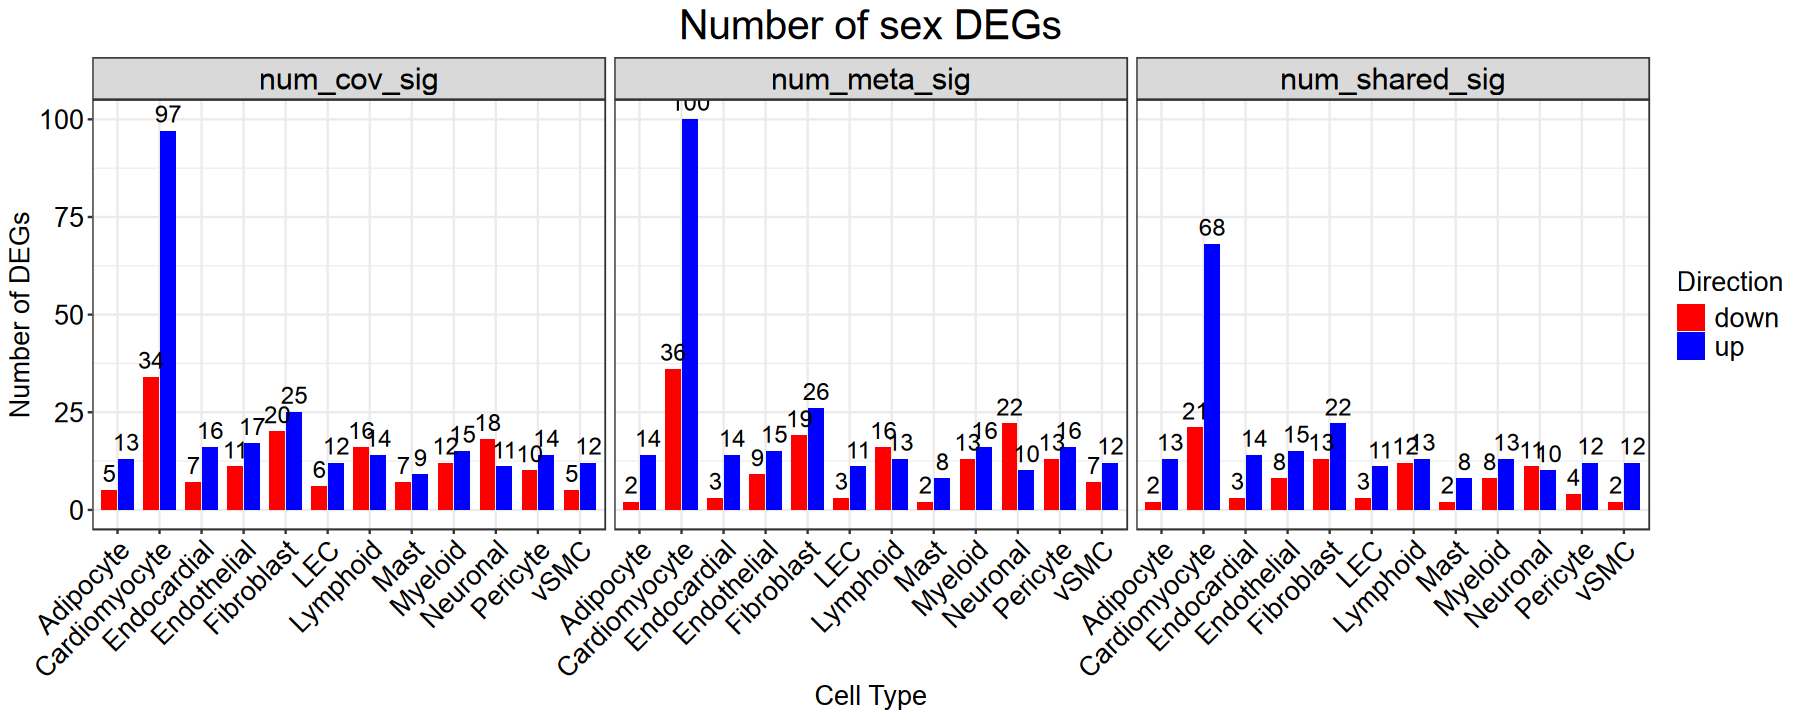

In [8]:
sex_res_long = collect_sig_counts(cell_types = cell_types, directions = directions, results_dir = "sex_results_dir/")
plot_deg_bar(sex_res_long) + ggtitle("Number of sex DEGs")

### Produce as a heatmap

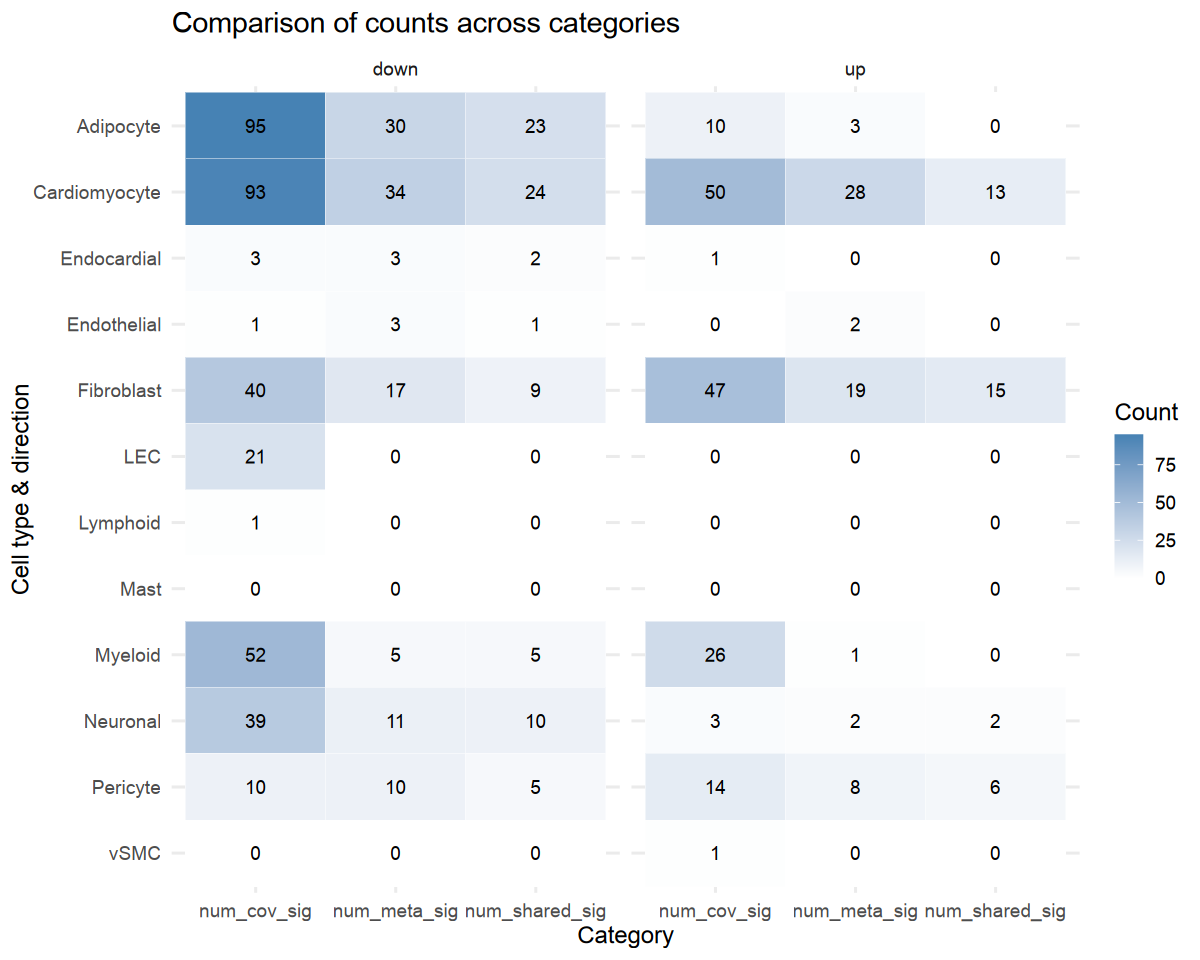

In [35]:
options(repr.plot.width = 10, repr.plot.height = 8)

p1 <- ggplot(age_res_long, aes(x = category, y = fct_rev(cell_type), fill = count)) +
  geom_tile(color = "white") + facet_wrap(~ direction) +
  geom_text(aes(label = count), color = "black") +
  scale_fill_gradient(low = "white", high = "steelblue") +
  labs(
    title = "Comparison of counts across categories",
    x = "Category",
    y = "Cell type & direction",
    fill = "Count"
  ) +
  theme_minimal(base_size = 14)

ggsave(p1, filename="04_covariate_meta_aging_overlap_plot.pdf", width = 10, height = 8)

p1

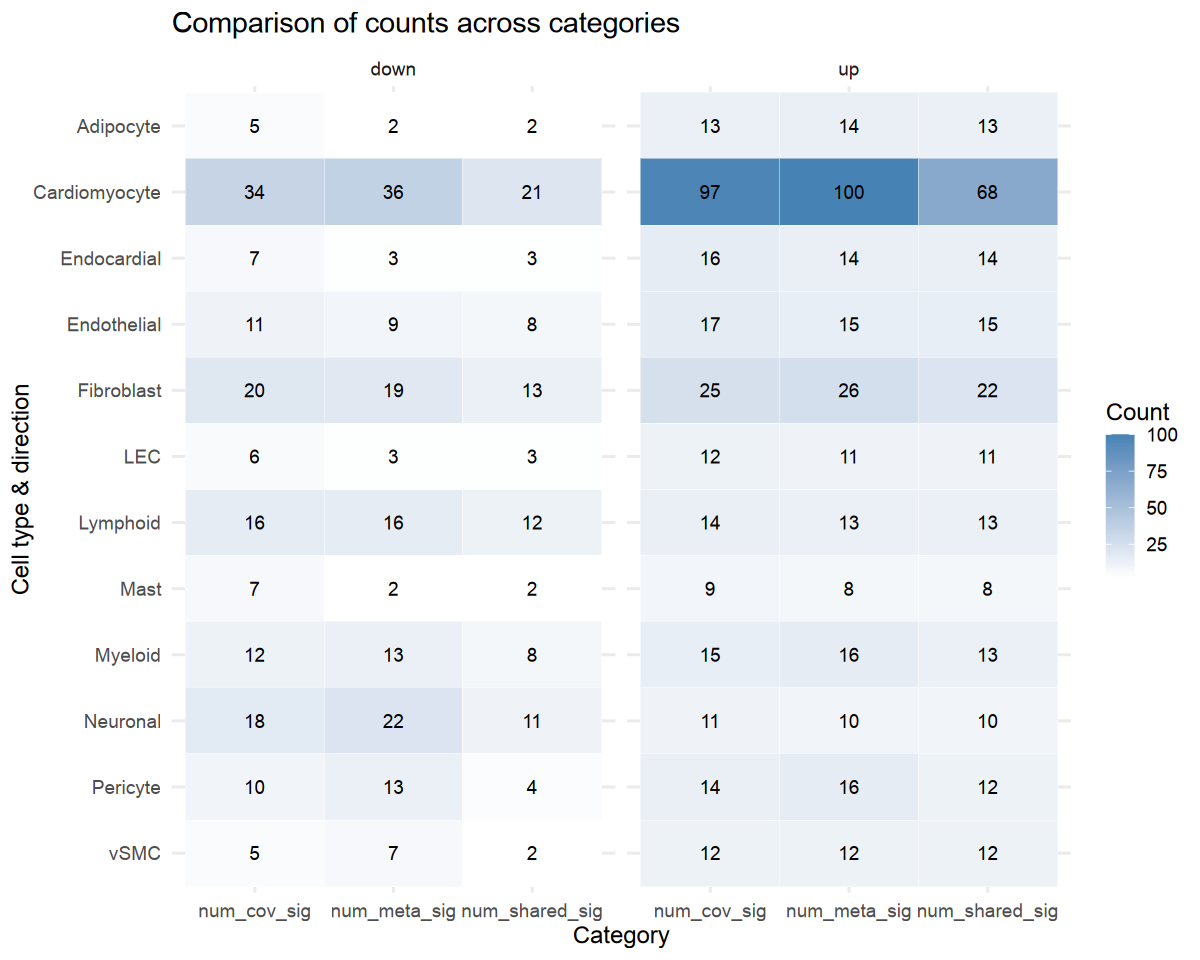

In [34]:
options(repr.plot.width = 10, repr.plot.height = 8)

p2 <- ggplot(sex_res_long, aes(x = category, y = fct_rev(cell_type), fill = count)) +
  geom_tile(color = "white") + facet_wrap(~ direction) +
  geom_text(aes(label = count), color = "black") +
  scale_fill_gradient(low = "white", high = "steelblue") +
  labs(
    title = "Comparison of counts across categories",
    x = "Category",
    y = "Cell type & direction",
    fill = "Count"
  ) +
  theme_minimal(base_size = 14)

ggsave(p2, filename="04_covariate_meta_sex_overlap_plot.pdf", width = 10, height = 8)

p2